# Burgers Multi-Case Example

This notebook follows the Burgers workflow in `Upload_version/Discovery_from_multicase.py` with a lightweight, reproducible setup. It loads the seven Burgers cases, checks array shapes, visualizes one case, and builds the train/validation split used by MCO-PDE.

All helper functions are loaded explicitly from `Upload_version/MTL_GA.py`, so this notebook does not import the root-level `MTL_GA.py` if another copy exists.

The full discovery, genetic search, and PIC selection stages are provided as separate optional code cells because they can take a long time.

## 1. Setup

The notebook can be launched either from the repository root or from the `Upload_version` directory.

In [19]:
from pathlib import Path
import importlib.util
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd()
if (cwd / "Upload_version").exists():
    repo_root = cwd
    upload_dir = cwd / "Upload_version"
else:
    upload_dir = cwd
    repo_root = cwd.parent

mtl_ga_path = upload_dir / "MTL_GA.py"
if not mtl_ga_path.exists():
    raise FileNotFoundError(f"Cannot find Upload_version/MTL_GA.py at {mtl_ga_path}")

spec = importlib.util.spec_from_file_location("upload_version_mtl_ga", mtl_ga_path)
mtl_ga = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mtl_ga)

build_xy_split = mtl_ga.build_xy_split
NN = mtl_ga.NN
pretrain_cases = mtl_ga.pretrain_cases
genetic_search = mtl_ga.genetic_search
genome_to_library = mtl_ga.genome_to_library
train_multicase_competitive = mtl_ga.train_multicase_competitive
compute_derivatives = mtl_ga.compute_derivatives

os.chdir(repo_root)

data_dir = repo_root / "data" / "Burgers_equation"
print(f"Working directory: {Path.cwd().as_posix()}")
print(f"Using data directory: {data_dir.relative_to(repo_root).as_posix()}")
print(f"Loaded helpers from: {mtl_ga_path.relative_to(repo_root).as_posix()}")

Working directory: e:/python_project/Discovery_from_multisource
Using data directory: data/Burgers_equation
Loaded helpers from: Upload_version/MTL_GA.py


## 2. Match the Burgers Configuration

In [20]:
prefix = "Burgers_IC"
LHS = "ut"
n_train = 100
n_valid = 100
seed = 42
noise_level = 0

print(f"prefix={prefix}, LHS={LHS}, n_train={n_train}, n_valid={n_valid}, seed={seed}")

prefix=Burgers_IC, LHS=ut, n_train=100, n_valid=100, seed=42


## 3. Load Burgers Cases

`Discovery_from_multicase.py` reads each CSV as a solution matrix `U`, then builds uniform `x` and `t` grids.

In [21]:
dataset = {}

for i in range(1, 8):
    path = data_dir / f"{prefix}{i}.csv"
    if not path.exists():
        print(f"[warn] missing: {path}")
        continue

    U = np.array(pd.read_csv(path, header=None))
    Nx, Nt = U.shape
    t = np.linspace(0, 10, Nt)
    x = np.linspace(-8, 8, Nx)
    key = f"{prefix}_{i}"
    dataset[key] = {"U": U, "t": t, "x": x}
    print(f"loaded {path.name}: U={U.shape}, x={x.shape}, t={t.shape}")

print(f"Loaded {len(dataset)} cases: {list(dataset.keys())}")

loaded Burgers_IC1.csv: U=(256, 201), x=(256,), t=(201,)
loaded Burgers_IC2.csv: U=(256, 201), x=(256,), t=(201,)
loaded Burgers_IC3.csv: U=(256, 201), x=(256,), t=(201,)
loaded Burgers_IC4.csv: U=(256, 201), x=(256,), t=(201,)
loaded Burgers_IC5.csv: U=(256, 201), x=(256,), t=(201,)
loaded Burgers_IC6.csv: U=(256, 201), x=(256,), t=(201,)
loaded Burgers_IC7.csv: U=(256, 201), x=(256,), t=(201,)
Loaded 7 cases: ['Burgers_IC_1', 'Burgers_IC_2', 'Burgers_IC_3', 'Burgers_IC_4', 'Burgers_IC_5', 'Burgers_IC_6', 'Burgers_IC_7']


## 4. Visualize One Case

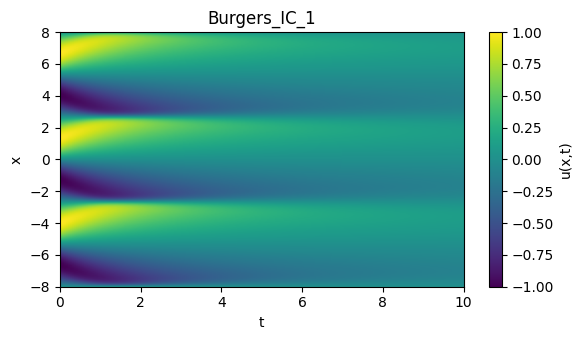

Plotted Burgers_IC_1 with U shape (256, 201).


In [22]:
case_key = "Burgers_IC_1"
case = dataset[case_key]
U, x, t = case["U"], case["x"], case["t"]

plt.figure(figsize=(6, 3.5))
plt.imshow(
    U,
    extent=[t.min(), t.max(), x.min(), x.max()],
    origin="lower",
    aspect="auto",
    cmap="viridis",
)
plt.colorbar(label="u(x,t)")
plt.xlabel("t")
plt.ylabel("x")
plt.title(case_key)
plt.tight_layout()
plt.show()

print(f"Plotted {case_key} with U shape {U.shape}.")

## 5. Build Train/Validation Splits

This uses the same `build_xy_split` helper loaded from `Upload_version/MTL_GA.py`.

In [23]:
split_dataset = {}

for key, data in dataset.items():
    X, Y, X_train, Y_train, X_valid, Y_valid = build_xy_split(
        data, n_train=n_train, n_valid=n_valid, seed=seed
    )
    split_dataset[key] = {
        "X_train": X_train,
        "Y_train": Y_train,
        "X_valid": X_valid,
        "Y_valid": Y_valid,
    }
    print(
        f"{key}: X={X.shape}, Y={Y.shape}, "
        f"X_train={X_train.shape}, Y_train={Y_train.shape}, "
        f"X_valid={X_valid.shape}, Y_valid={Y_valid.shape}"
    )

Burgers_IC_1: X=(51456, 2), Y=(51456, 1), X_train=(100, 2), Y_train=(100, 1), X_valid=(100, 2), Y_valid=(100, 1)
Burgers_IC_2: X=(51456, 2), Y=(51456, 1), X_train=(100, 2), Y_train=(100, 1), X_valid=(100, 2), Y_valid=(100, 1)
Burgers_IC_3: X=(51456, 2), Y=(51456, 1), X_train=(100, 2), Y_train=(100, 1), X_valid=(100, 2), Y_valid=(100, 1)
Burgers_IC_4: X=(51456, 2), Y=(51456, 1), X_train=(100, 2), Y_train=(100, 1), X_valid=(100, 2), Y_valid=(100, 1)
Burgers_IC_5: X=(51456, 2), Y=(51456, 1), X_train=(100, 2), Y_train=(100, 1), X_valid=(100, 2), Y_valid=(100, 1)
Burgers_IC_6: X=(51456, 2), Y=(51456, 1), X_train=(100, 2), Y_train=(100, 1), X_valid=(100, 2), Y_valid=(100, 1)
Burgers_IC_7: X=(51456, 2), Y=(51456, 1), X_train=(100, 2), Y_train=(100, 1), X_valid=(100, 2), Y_valid=(100, 1)


## 6. Optional Model Setup and Pretraining

This block creates one neural network per case and calls `pretrain_cases`. Keep it disabled for a quick example run.

In [24]:
RUN_PRETRAIN =True
models = None

if RUN_PRETRAIN:
    import torch

    discovery_device = "cuda" if torch.cuda.is_available() else "cpu"
    models = [
        NN(
            Num_Hidden_Layers=5,
            Neurons_Per_Layer=50,
            Input_Dim=2,
            Output_Dim=1,
            Data_Type=torch.float32,
            Device=discovery_device,
            Activation_Function="Sin",
            Batch_Norm=False,
        )
        for _ in split_dataset
    ]
    optimizers = [torch.optim.Adam(m.parameters(), lr=1e-3) for m in models]
    model_log_dir = repo_root / "model_save" / f"{prefix}_{n_train}"
    model_log_dir.mkdir(parents=True, exist_ok=True)
    pretrain_cases(
        models,
        split_dataset,
        optimizers,
        n_train=n_train,
        n_valid=n_valid,
        device=discovery_device,
        log_dir=str(model_log_dir),
        seed=seed,
        log_interval=10000,
    )
    print(f"Pretrained {len(models)} models on {discovery_device}.")
else:
    print("Pretraining is disabled. Set RUN_PRETRAIN = True to run it.")

[skip] Burgers_IC_1_100 already trained: e:\python_project\Discovery_from_multisource\model_save\Burgers_IC_100\model_Burgers_IC_1_100\checkpoint_best.pt
[skip] Burgers_IC_2_100 already trained: e:\python_project\Discovery_from_multisource\model_save\Burgers_IC_100\model_Burgers_IC_2_100\checkpoint_best.pt
[skip] Burgers_IC_3_100 already trained: e:\python_project\Discovery_from_multisource\model_save\Burgers_IC_100\model_Burgers_IC_3_100\checkpoint_best.pt
[skip] Burgers_IC_4_100 already trained: e:\python_project\Discovery_from_multisource\model_save\Burgers_IC_100\model_Burgers_IC_4_100\checkpoint_best.pt
[skip] Burgers_IC_5_100 already trained: e:\python_project\Discovery_from_multisource\model_save\Burgers_IC_100\model_Burgers_IC_5_100\checkpoint_best.pt
[skip] Burgers_IC_6_100 already trained: e:\python_project\Discovery_from_multisource\model_save\Burgers_IC_100\model_Burgers_IC_6_100\checkpoint_best.pt
[skip] Burgers_IC_7_100 already trained: e:\python_project\Discovery_from_mu

## 7. Optional Genetic Search

This cell is intentionally separate from pretraining. It runs only the `genetic_search` call, matching the `Discover` branch in `Discovery_from_multicase.py`.

In [25]:
RUN_GENETIC_SEARCH = True

if RUN_GENETIC_SEARCH:
    if models is None:
        raise RuntimeError("Run the pretraining cell first with RUN_PRETRAIN = True.")

    ga_save_dir = repo_root / "result_save" / f"{prefix}_{n_train}_{len(split_dataset)}"
    ga_save_dir.mkdir(parents=True, exist_ok=True)
    print(f"GA output directory: {ga_save_dir.relative_to(repo_root).as_posix()}")

    best_genome, best_score, best_info = genetic_search(
        models=models,
        cases=split_dataset,
        prefix=prefix,
        n_train=n_train,
        n_valid=n_valid,
        seed=seed,
        LHS=LHS,
        pop_size=50,
        generations=10,
        PINN_num_epoch=500,
    )
    print("Best genome:", best_genome)
    print("Best loss:", best_score)
else:
    print("Genetic search is disabled. Set RUN_GENETIC_SEARCH = True after pretraining.")

GA output directory: result_save/Burgers_IC_100_7
#################   Generation 0/10   #####################
=================Evaluate [['uxxx']], 0/50===============


100%|██████████| 500/500 [00:32<00:00, 15.45it/s]


data=3.101187e-03 pde=1.334458e-02 fitness=4.138405e-05 beta=[-2.2428e-03]
  Burgers_IC_1: w=0.143 beta=[-2.0288e-03]
  Burgers_IC_2: w=0.137 beta=[-2.3883e-03]
  Burgers_IC_3: w=0.219 beta=[-2.3095e-03]
  Burgers_IC_4: w=0.157 beta=[-5.2508e-03]
  Burgers_IC_5: w=0.100 beta=[-3.3246e-03]
  Burgers_IC_6: w=0.122 beta=[-9.6931e-06]
  Burgers_IC_7: w=0.123 beta=[-1.2514e-03]
  uxxx: -2.2428e-03±1.5191e-03

=================Evaluate [['u', 'u'], ['uxxx'], ['ux']], 1/50===============


100%|██████████| 500/500 [00:33<00:00, 14.96it/s]


data=3.106701e-03 pde=1.343658e-02 fitness=4.174343e-05 beta=[5.1758e-03, -1.6579e-03, 1.9942e-02]
  Burgers_IC_1: w=0.133 beta=[4.1336e-02, -2.9437e-03, -6.2748e-03]
  Burgers_IC_2: w=0.182 beta=[-1.7151e-02, -1.0930e-03, 3.9415e-02]
  Burgers_IC_3: w=0.180 beta=[2.2835e-02, -1.7716e-03, 2.4614e-02]
  Burgers_IC_4: w=0.157 beta=[-1.2191e-02, -7.6759e-03, -1.3965e-02]
  Burgers_IC_5: w=0.115 beta=[-2.2840e-02, -4.1502e-04, 6.3386e-02]
  Burgers_IC_6: w=0.114 beta=[-5.9004e-04, 7.4360e-04, 1.6598e-02]
  Burgers_IC_7: w=0.119 beta=[-4.9166e-03, -1.2279e-03, 1.0044e-03]
  u*u: 5.1758e-03±2.1424e-02
  uxxx: -1.6579e-03±2.5241e-03
  ux: 1.9942e-02±2.5253e-02

=================Evaluate [['uxxx']], 2/50===============
fitness have been computed: 4.138404864991417e-05
=================Evaluate [['ux', 'u'], ['uxxx', 'u'], ['ux', 'uxx', 'u'], ['uxxx']], 3/50===============


...

data=4.304220e-03 pde=1.395562e-02 fitness=6.006805e-05 beta=[5.8329e-02, 5.0259e-02]
  Burgers_IC_1: w=0.233 beta=[5.5409e-02, 4.7753e-02]
  Burgers_IC_2: w=0.022 beta=[5.9292e-02, 3.1182e-02]
  Burgers_IC_3: w=0.173 beta=[4.4578e-02, 5.1104e-02]
  Burgers_IC_4: w=0.350 beta=[6.7945e-02, 4.6216e-02]
  Burgers_IC_5: w=0.032 beta=[6.5641e-02, 5.5970e-02]
  Burgers_IC_6: w=0.165 beta=[6.1240e-02, 4.1534e-02]
  Burgers_IC_7: w=0.025 beta=[3.2750e-02, 3.8482e-02]
  uxx: 5.8329e-02±1.1597e-02
  uxxx*u: 5.0259e-02±7.6626e-03

=================Evaluate [['u', 'ux'], ['u', 'u', 'u'], ['uxxx'], ['uxx']], 36/50===============


100%|██████████| 500/500 [00:34<00:00, 14.41it/s]


data=2.871840e-04 pde=9.720994e-04 fitness=2.791714e-07 beta=[-8.9172e-01, -7.7721e-03, -5.4720e-04, 1.0688e-01]
  Burgers_IC_1: w=0.139 beta=[-8.5248e-01, -2.5086e-02, 4.8753e-05, 1.0588e-01]
  Burgers_IC_2: w=0.155 beta=[-9.3507e-01, -2.7634e-03, 8.5375e-04, 1.0864e-01]
  Burgers_IC_3: w=0.138 beta=[-8.6358e-01, -1.3281e-02, -6.4386e-04, 1.0467e-01]
  Burgers_IC_4: w=0.133 beta=[-8.2908e-01, -3.4913e-02, -9.8939e-04, 1.0358e-01]
  Burgers_IC_5: w=0.148 beta=[-9.3360e-01, -1.1134e-02, -9.2480e-04, 1.0775e-01]
  Burgers_IC_6: w=0.147 beta=[-9.1962e-01, -8.8742e-03, -5.0675e-04, 1.1064e-01]
  Burgers_IC_7: w=0.139 beta=[-8.7421e-01, -1.6328e-02, -7.0618e-04, 1.0606e-01]
  u*ux: -8.9172e-01±3.9286e-02
  u*u*u: -7.7721e-03±9.9814e-03
  uxxx: -5.4720e-04±6.0474e-04
  uxx: 1.0688e-01±2.2447e-03

=================Evaluate [['uxxx']], 37/50===============
fitness have been computed: 4.138404864991417e-05
=================Evaluate [['uxxx']], 38/50===============
fitness have been computed: 4.

100%|██████████| 500/500 [00:34<00:00, 14.35it/s]

data=3.703147e-03 pde=1.505249e-02 fitness=5.574156e-05 beta=[1.0625e-01, 1.7654e-02, -2.3250e-03, -3.5503e-02]
  Burgers_IC_1: w=0.152 beta=[4.0794e-02, -1.6716e-02, -3.6458e-03, -3.1735e-03]
  Burgers_IC_2: w=0.191 beta=[3.8028e-02, 1.3489e-02, -3.9948e-03, -6.8767e-02]
  Burgers_IC_3: w=0.163 beta=[3.2126e-02, -1.3272e-03, -3.8109e-03, -3.1421e-02]
  Burgers_IC_4: w=0.131 beta=[2.0985e-01, -1.0142e-02, -7.6146e-03, -5.5609e-02]
  Burgers_IC_5: w=0.137 beta=[4.5822e-02, 4.4423e-02, -9.4406e-04, -9.9309e-02]
  Burgers_IC_6: w=0.129 beta=[8.1607e-02, 2.3383e-02, 1.2702e-03, -1.1153e-02]
  Burgers_IC_7: w=0.096 beta=[2.1158e-02, 1.0467e-02, -3.7872e-05, 1.1456e-02]
  u*uxx*ux: 1.0625e-01±6.0843e-02
  ux: 1.7654e-02±1.9340e-02
  uxxx: -2.3250e-03±2.7746e-03
  ux*ux: -3.5503e-02±3.6702e-02

=================Evaluate [['uxxx'], ['uxx']], 40/50===============
fitness have been computed: 4.93443123636742e-05
=================Evaluate [['u', 'ux'], ['uxxx'], ['u']], 41/50===============
fitne

## 8. Optional PIC Selection

This block mirrors the `PIC_select` branch. It loads the cached best genome, trains the multicase competitive model with that library, ranks terms by coefficient variation, and saves the final selected result.

In [27]:
RUN_PIC_SELECT = True

if RUN_PIC_SELECT:
    import json
    import pickle
    import torch

    rng = np.random.default_rng(seed)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    cache_path = repo_root / "result_save" / f"{prefix}_{n_train}_{len(dataset)}" / "fitness_cache.pkl"
    if not cache_path.exists():
        raise FileNotFoundError(f"No fitness cache found: {cache_path}")

    with open(cache_path, "rb") as f:
        fitness_cache = pickle.load(f)

    sorted_items = sorted(fitness_cache.items(), key=lambda kv: kv[1][0])
    best_genome = sorted_items[0][0]
    print(f"Best cached genome: {best_genome}")

    pic_models = [
        NN(
            Num_Hidden_Layers=5,
            Neurons_Per_Layer=50,
            Input_Dim=2,
            Output_Dim=1,
            Data_Type=torch.float32,
            Device=device,
            Activation_Function="Sin",
            Batch_Norm=False,
        )
        for _ in split_dataset
    ]

    library_fn, term_names = genome_to_library(best_genome)
    pic_models, _ = train_multicase_competitive(
        models=pic_models,
        cases=split_dataset,
        prefix=prefix,
        LHS=LHS,
        num_epochs=1000,
        n_train=n_train,
        n_valid=n_valid,
        seed=seed,
        n_colloc=1000,
        library_fn=library_fn,
        return_metrics=False,
    )

    data_cache = []
    case_keys = list(split_dataset.keys())
    for key in case_keys:
        X_train = split_dataset[key]["X_train"]
        x_min, x_max = float(X_train[:, 0].min()), float(X_train[:, 0].max())
        t_min, t_max = float(X_train[:, 1].min()), float(X_train[:, 1].max())
        data_cache.append((x_min, x_max, t_min, t_max))

    beta_all = []
    for case_idx, key in enumerate(case_keys):
        model = pic_models[case_idx].to(device).eval()
        x_min, x_max, t_min, t_max = data_cache[case_idx]
        x_c = rng.uniform(x_min, x_max, size=(1000, 1))
        t_c = rng.uniform(t_min, t_max, size=(1000, 1))
        Xc_np = np.hstack([x_c, t_c])
        Xc = torch.from_numpy(Xc_np).float().to(device)
        Xc.requires_grad_(True)

        u_c = model(Xc).reshape(-1, 1)
        left_u_t, u_x, u_xx, u_xxx = compute_derivatives(u_c, Xc, LHS=LHS)
        lib_out = library_fn(u_c, u_x, u_xx, u_xxx)
        if isinstance(lib_out, tuple):
            Phi, lib_names = lib_out
            if term_names is None:
                term_names = lib_names
        else:
            Phi = lib_out

        sigma = torch.sqrt((Phi ** 2).mean(dim=0, keepdim=True)) + 1e-8
        Phi_s = Phi / sigma
        beta_s = torch.linalg.lstsq(Phi_s, left_u_t).solution
        beta = beta_s / sigma.T
        beta_all.append(beta)

    beta_mat = torch.cat([b.detach().cpu() for b in beta_all], dim=1).numpy()
    beta_mean = np.mean(beta_mat, axis=1)
    beta_std = np.std(beta_mat, axis=1)
    cv = beta_std / (np.abs(beta_mean) + 1e-12)
    cv_sorted_idx = np.argsort(cv)

    print("CV ranking:")
    for idx in cv_sorted_idx:
        print(f"{term_names[idx]}: cv={cv[idx]:.4e}")

    term_names_joined = ["*".join(term) for term in best_genome]
    sorted_term_names = [term_names_joined[i] for i in cv_sorted_idx]
    term_cv = {term_names_joined[i]: cv[i] for i in range(len(term_names_joined))}

    results = []
    current_genome = []
    for step, term_name in enumerate(sorted_term_names, start=1):
        added = next((list(term) for term in best_genome if "*".join(term) == term_name), None)
        if added is None:
            continue

        current_genome.append(added)
        library_fn_step, _ = genome_to_library(current_genome)
        metrics = train_multicase_competitive(
            models=pic_models,
            cases=split_dataset,
            prefix=prefix,
            LHS=LHS,
            num_epochs=1000,
            n_train=n_train,
            n_valid=n_valid,
            seed=seed,
            n_colloc=1000,
            library_fn=library_fn_step,
            return_metrics=True,
        )
        fitness_val = metrics["loss_data"] * metrics["loss_pde"]
        current_terms = ["*".join(term) for term in current_genome]
        cv_mean = np.mean([term_cv[name] for name in current_terms])
        score = fitness_val * cv_mean
        results.append((current_genome.copy(), fitness_val, cv_mean, score))
        print(f"[step {step}] added={added}, score={score:.6e}")

    best = min(results, key=lambda item: item[3])
    final_selected = {
        "genome": best[0],
        "fitness": float(best[1]),
        "cv_mean": float(best[2]),
        "score": float(best[3]),
    }

    out_dir = repo_root / "result_save" / f"{prefix}_{n_train}_{len(dataset)}"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / "final_discovered_equations.json"
    payload = {
        "all_genomes_and_metrics": [
            {"genome": g, "fitness": float(fval), "cv_mean": float(cvm), "score": float(sc)}
            for g, fval, cvm, sc in results
        ],
        "final_selected": final_selected,
        "cv_list": [
            {"term": term_names[idx], "cv": float(cv[idx])}
            for idx in cv_sorted_idx
        ],
    }
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)

    print(f"Saved PIC selection result to {out_path.relative_to(repo_root).as_posix()}")
else:
    print("PIC selection is disabled. Set RUN_PIC_SELECT = True after a fitness cache is available.")

Best cached genome: (('u', 'ux'), ('uxx',))


100%|██████████| 1000/1000 [00:54<00:00, 18.19it/s]


data=1.447040e-04 pde=4.243015e-04 fitness=6.139811e-08 beta=[-9.4893e-01, 1.1257e-01]
  Burgers_IC_1: w=0.143 beta=[-9.2485e-01, 1.0963e-01]
  Burgers_IC_2: w=0.151 beta=[-9.6536e-01, 1.1088e-01]
  Burgers_IC_3: w=0.136 beta=[-9.3008e-01, 1.1146e-01]
  Burgers_IC_4: w=0.143 beta=[-9.3384e-01, 1.0960e-01]
  Burgers_IC_5: w=0.143 beta=[-9.6445e-01, 1.1559e-01]
  Burgers_IC_6: w=0.142 beta=[-9.6067e-01, 1.1258e-01]
  Burgers_IC_7: w=0.141 beta=[-9.5722e-01, 1.1474e-01]
  u*ux: -9.4893e-01±1.6368e-02
  uxx: 1.1257e-01±2.1912e-03

CV ranking:
u*ux: cv=1.3895e-02
uxx: cv=2.5250e-02


100%|██████████| 1000/1000 [00:42<00:00, 23.61it/s]


data=2.236208e-03 pde=1.223856e-02 fitness=2.736796e-05 beta=[-8.3359e-01]
  Burgers_IC_1: w=0.061 beta=[-6.4531e-01]
  Burgers_IC_2: w=0.306 beta=[-8.4358e-01]
  Burgers_IC_3: w=0.019 beta=[-3.7499e-01]
  Burgers_IC_4: w=0.031 beta=[-7.4847e-01]
  Burgers_IC_5: w=0.305 beta=[-8.8083e-01]
  Burgers_IC_6: w=0.214 beta=[-9.0780e-01]
  Burgers_IC_7: w=0.065 beta=[-5.3325e-01]
  u*ux: -8.3359e-01±1.8327e-01

[step 1] added=['u', 'ux'], score=3.802706e-07


100%|██████████| 1000/1000 [00:48<00:00, 20.50it/s]

data=1.447909e-04 pde=4.256046e-04 fitness=6.162366e-08 beta=[-9.4915e-01, 1.1271e-01]
  Burgers_IC_1: w=0.143 beta=[-9.3189e-01, 1.0918e-01]
  Burgers_IC_2: w=0.152 beta=[-9.6351e-01, 1.0956e-01]
  Burgers_IC_3: w=0.135 beta=[-9.3056e-01, 1.1095e-01]
  Burgers_IC_4: w=0.142 beta=[-9.3743e-01, 1.1020e-01]
  Burgers_IC_5: w=0.145 beta=[-9.6044e-01, 1.1386e-01]
  Burgers_IC_6: w=0.142 beta=[-9.5571e-01, 1.1330e-01]
  Burgers_IC_7: w=0.142 beta=[-9.6212e-01, 1.1566e-01]
  u*ux: -9.4915e-01±1.3758e-02
  uxx: 1.1271e-01±2.2859e-03

[step 2] added=['uxx'], score=1.206112e-09
Saved PIC selection result to result_save/Burgers_IC_100_7/final_discovered_equations.json
